In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gcamreader
from pathlib import Path

GCAM_ROOT    = Path('/Users/parkercaswell/gcam')
HECTOR_LOG   = GCAM_ROOT / 'exe/logs/gcam-hector-outputstream.csv'
DB_PATH      = GCAM_ROOT / 'output'
DB_NAME      = 'database_basexdb'
QUERIES_PATH = GCAM_ROOT / 'output/queries/Main_queries.xml'

TARGET_4P5 = 4.5
TARGET_3P7 = 3.7

# Colors keyed by hector-stream scenario name (not DB name)
SCENARIO_COLORS = {
    'Reference':             '#aaaaaa',
    'GCAM_SSP1_2p6':         '#52b788',
    'GCAM_SSP1_1p9':         '#1a7340',
    'GCAM_SSP2_3p7':         '#1a5276',
    'GCAM_SSP2_4p5':         '#3498db',   # overshoot run (written as GCAM_SSP2_4p5, now GCAM_SSP2_4p5_os in DB)
    'GCAM_SSP2_4p5_tol15':   '#e67e22',   # tol=0.15%, no overshoot
    'GCAM_SSP2_4p5_stab':    '#e74c3c',   # stuck stab run
}

SCENARIO_LABELS = {
    'Reference':             'Reference',
    'GCAM_SSP1_2p6':         'SSP1-2.6',
    'GCAM_SSP1_1p9':         'SSP1-1.9',
    'GCAM_SSP2_3p7':         'SSP2-3.7',
    'GCAM_SSP2_4p5':         'SSP2-4.5 (overshoot)',
    'GCAM_SSP2_4p5_tol15':   'SSP2-4.5 (tol=0.15%)',
    'GCAM_SSP2_4p5_stab':    'SSP2-4.5 stab (stuck)',
}


In [33]:
# ── Parse hector output stream ──────────────────────────────────────────────
# Each GCAM dispatch runs Hector twice (run_idx 0 and 1); values are identical.
# We keep run_idx == 0 and assign a dispatch_id by detecting year resets.

df_raw = pd.read_csv(
    HECTOR_LOG, header=None,
    names=['year','scenario','run_idx','component','variable','value','unit']
)
df_raw = df_raw[df_raw['run_idx'] == 0].copy()
df_raw['year']  = pd.to_numeric(df_raw['year'],  errors='coerce')
df_raw['value'] = pd.to_numeric(df_raw['value'], errors='coerce')
df_raw = df_raw.dropna(subset=['year','value'])
df_raw['year'] = df_raw['year'].astype(int)

# Assign dispatch IDs
dispatch_ids = []
d_id, prev_yr = 0, 0
for yr in df_raw['year']:
    if yr < prev_yr:
        d_id += 1
    dispatch_ids.append(d_id)
    prev_yr = yr
df_raw['dispatch'] = dispatch_ids

n_dispatches = df_raw['dispatch'].max() + 1
print(f'Total dispatches in log: {n_dispatches}')
print(f'Year range: {df_raw["year"].min()}–{df_raw["year"].max()}')
print(f'Unique variables: {df_raw["variable"].nunique()}')

/var/folders/sw/m6fvzsm96871n4jwc5ny38240000gn/T/ipykernel_58199/2941899480.py:5: DtypeWarning: Columns (0: year, 1: run_idx, 2: value) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(


Total dispatches in log: 46
Year range: 1746–2100
Unique variables: 95


In [34]:
# ── Identify dispatches and best converged dispatch ─────────────────────────
# Hector stream run_name is always "ssp119" (internal Hector label, not GCAM
# scenario name). Runs are separated by detecting where RF_2100 jumps back up
# after having converged — indicating a new GCAM run started.

rf2100 = (
    df_raw[(df_raw["year"] == 2100) & (df_raw["variable"] == "RF_tot")]
    .groupby("dispatch")["value"].first()
)

# Detect run boundaries: RF_2100 jumps > 1 W/m² upward = new run starting
rf_sorted = rf2100.sort_index()
run_labels = {}
current_run = 0
for i, (d, v) in enumerate(rf_sorted.items()):
    if i > 0 and v > rf_sorted.iloc[i-1] + 1.0:
        current_run += 1
    run_labels[d] = current_run
n_runs = current_run + 1

print(f"Detected {n_runs} run(s) in hector stream")
run_best = {}
for run_id in range(n_runs):
    dispatches = [d for d, r in run_labels.items() if r == run_id]
    vals = rf2100[dispatches]
    bd = (vals - TARGET_4P5).abs().idxmin()
    run_best[run_id] = bd
    print(f"  Run {run_id}: dispatches {min(dispatches)}-{max(dispatches)}, "
          f"RF_2100 {vals.min():.3f}-{vals.max():.3f}, best={bd} ({rf2100[bd]:.4f} W/m²)")

# best_dispatch = best converged dispatch of the LAST (most recent) run
best_dispatch = run_best[n_runs - 1]

# overshoot_mask: dispatches of run 0 (for Plot 1 convergence path)
run0_dispatches = [d for d, r in run_labels.items() if r == 0]
overshoot_mask = rf2100.index.isin(run0_dispatches)

print(f"\nBest dispatch (most recent run): {best_dispatch}, "
      f"RF_tot 2100 = {rf2100[best_dispatch]:.4f} W/m²")


Detected 1 run(s) in hector stream
  Run 0: dispatches 1-45, RF_2100 4.437-6.573, best=39 (4.5010 W/m²)

Best dispatch (most recent run): 39, RF_tot 2100 = 4.5010 W/m²


In [35]:
# ── Helper ───────────────────────────────────────────────────────────────────
def get(dispatch, variable, yr_min=1950):
    mask = (
        (df_raw['dispatch'] == dispatch) &
        (df_raw['variable'] == variable) &
        (df_raw['year'] >= yr_min)
    )
    return df_raw[mask].set_index('year')['value'].sort_index()

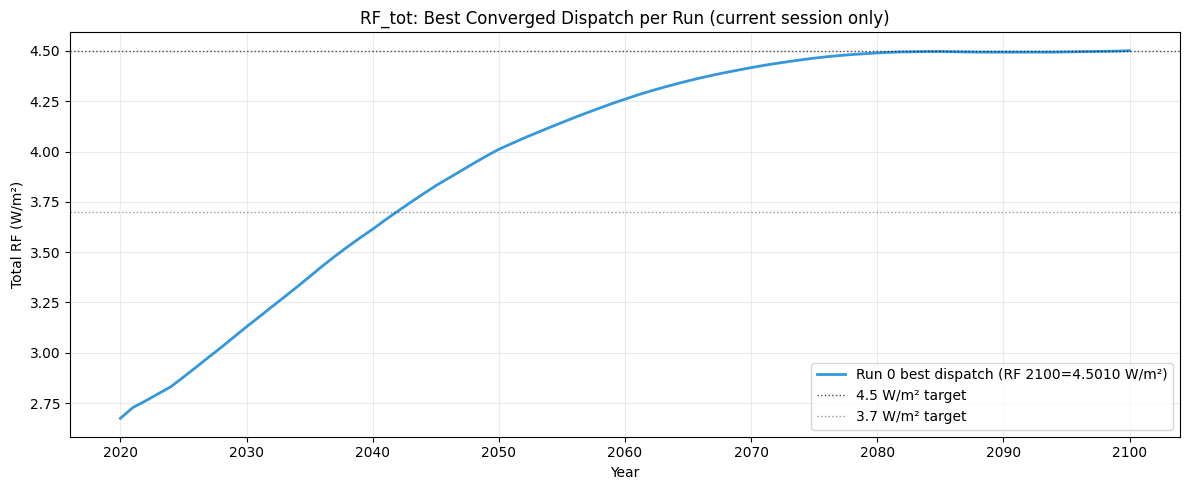

In [36]:
# ── RF comparison: best dispatch per detected run ───────────────────────────
# Each run in the hector stream gets one line (its best converged dispatch).
# Note: hector stream is overwritten each GCAM session, so only runs from the
# current session appear here. Cross-session RF comparison requires saving
# hector data per scenario.
RUN_COLORS  = ["#3498db", "#e67e22", "#e74c3c", "#27ae60", "#9b59b6"]

fig, ax = plt.subplots(figsize=(12, 5))
for run_id, bd in run_best.items():
    s = get(bd, "RF_tot", 2020)
    color = RUN_COLORS[run_id % len(RUN_COLORS)]
    ax.plot(s.index, s.values, color=color, lw=2,
            label=f"Run {run_id} best dispatch (RF 2100={rf2100[bd]:.4f} W/m²)")
ax.axhline(TARGET_4P5, color="black", lw=1.0, ls=":", alpha=0.7, label="4.5 W/m² target")
ax.axhline(TARGET_3P7, color="black", lw=1.0, ls=":", alpha=0.4, label="3.7 W/m² target")
ax.set_xlabel("Year")
ax.set_ylabel("Total RF (W/m²)")
ax.set_title("RF_tot: Best Converged Dispatch per Run (current session only)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


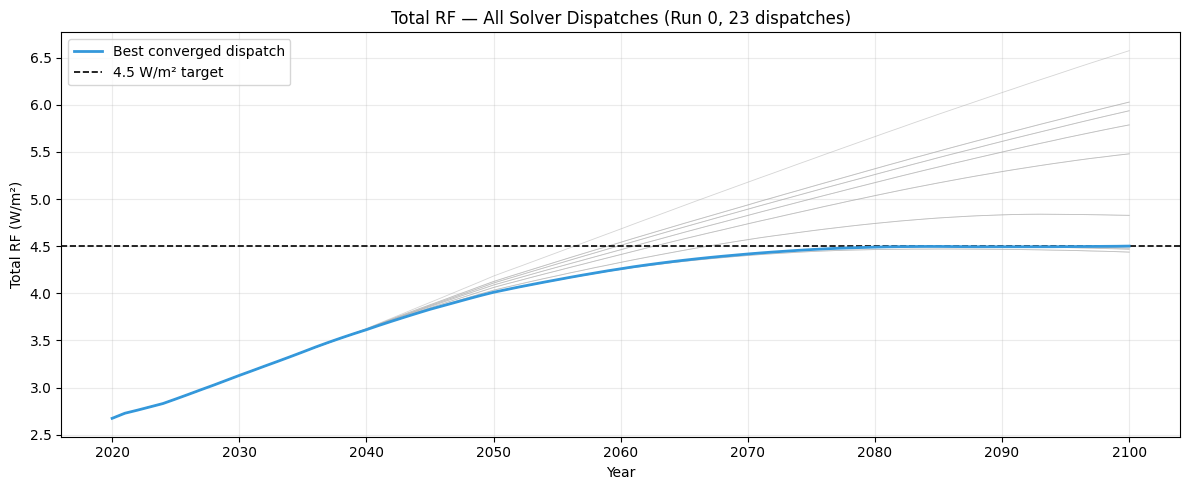

In [37]:
# ── Plot 1: RF_tot solver convergence path ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for d in rf2100[overshoot_mask].index:
    s = get(d, 'RF_tot', 2020)
    if d == best_dispatch:
        ax.plot(s.index, s.values, color='#3498db', lw=2.0, zorder=5, label='Best converged dispatch')
    else:
        ax.plot(s.index, s.values, color='#aaaaaa', lw=0.6, alpha=0.5)

ax.axhline(TARGET_4P5, color='black', lw=1.2, ls='--', label='4.5 W/m² target')
ax.set_xlabel('Year')
ax.set_ylabel('Total RF (W/m²)')
ax.set_title(f'Total RF — All Solver Dispatches (Run 0, {len(run0_dispatches)} dispatches)')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

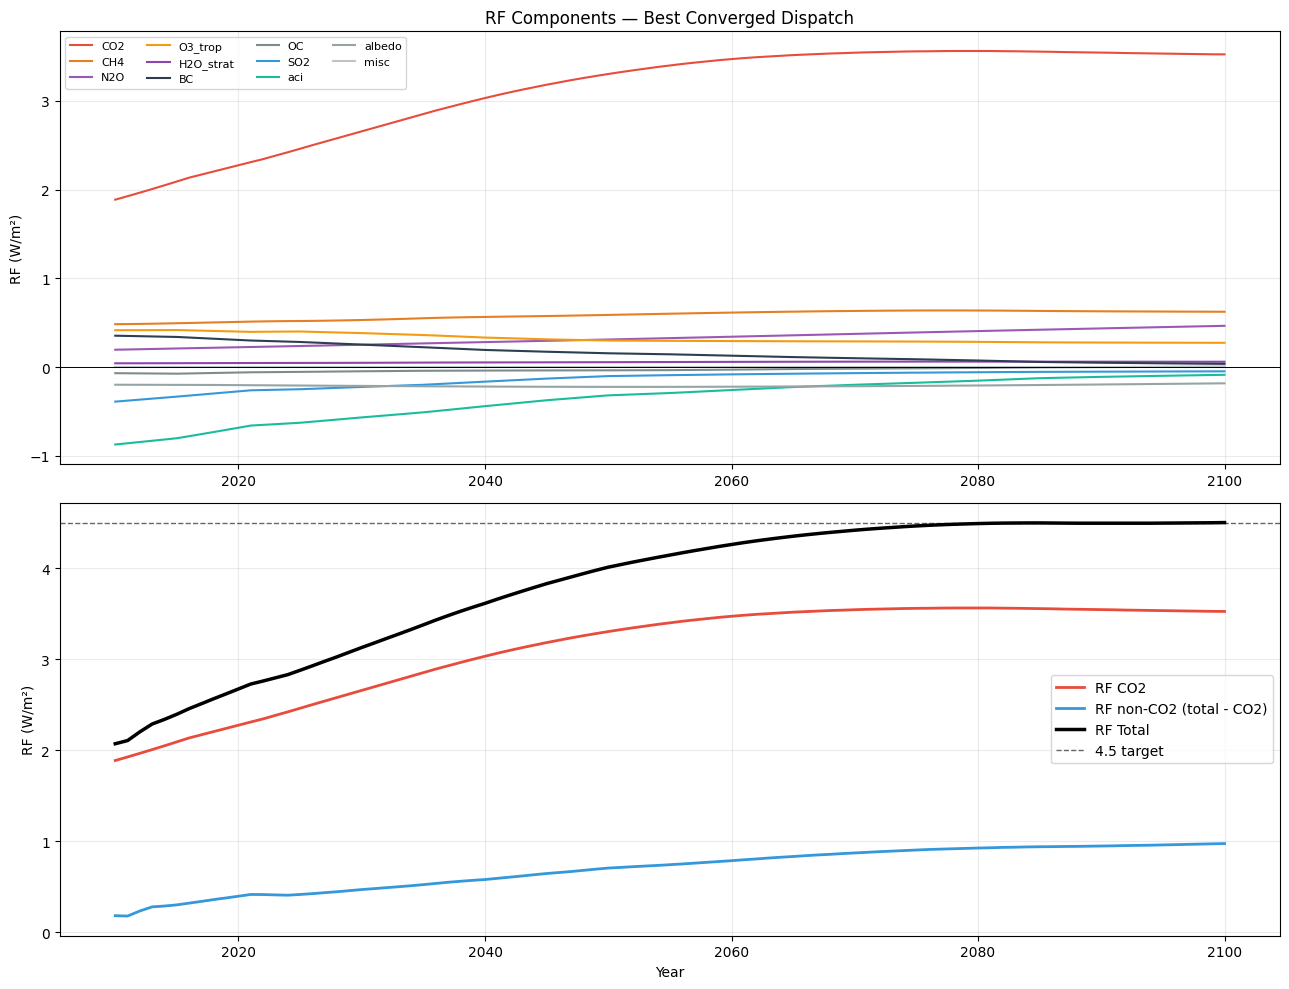

In [38]:
# ── Plot 2: RF components breakdown ─────────────────────────────────────────
COMP_COLORS = {
    'RF_CO2':    '#e74c3c',
    'FCH4':      '#e67e22',
    'RF_N2O':    '#9b59b6',
    'RF_O3_trop':'#f39c12',
    'RF_H2O_strat':'#8e44ad',
    'RF_BC':     '#2c3e50',
    'RF_OC':     '#7f8c8d',
    'RF_SO2':    '#3498db',
    'RF_aci':    '#1abc9c',
    'RF_albedo': '#95a5a6',
    'RF_misc':   '#bdc3c7',
}

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Top: individual components
ax = axes[0]
for var, col in COMP_COLORS.items():
    s = get(best_dispatch, var, 2010)
    if not s.empty:
        ax.plot(s.index, s.values, color=col, lw=1.5,
                label=var.replace('RF_','').replace('FCH4','CH4'))
ax.axhline(0, color='black', lw=0.7)
ax.set_ylabel('RF (W/m²)')
ax.set_title('RF Components — Best Converged Dispatch')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.25)

# Bottom: CO2 vs non-CO2 vs total
ax = axes[1]
rf_co2 = get(best_dispatch, 'RF_CO2', 2010)
rf_tot = get(best_dispatch, 'RF_tot', 2010)
common = rf_co2.index.intersection(rf_tot.index)
non_co2 = rf_tot.loc[common] - rf_co2.loc[common]

ax.plot(rf_co2.index, rf_co2.values, color='#e74c3c', lw=2, label='RF CO2')
ax.plot(non_co2.index, non_co2.values, color='#3498db', lw=2, label='RF non-CO2 (total - CO2)')
ax.plot(rf_tot.index, rf_tot.values, color='black', lw=2.5, label='RF Total')
ax.axhline(TARGET_4P5, color='black', lw=1, ls='--', alpha=0.6, label='4.5 target')
ax.set_xlabel('Year')
ax.set_ylabel('RF (W/m²)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

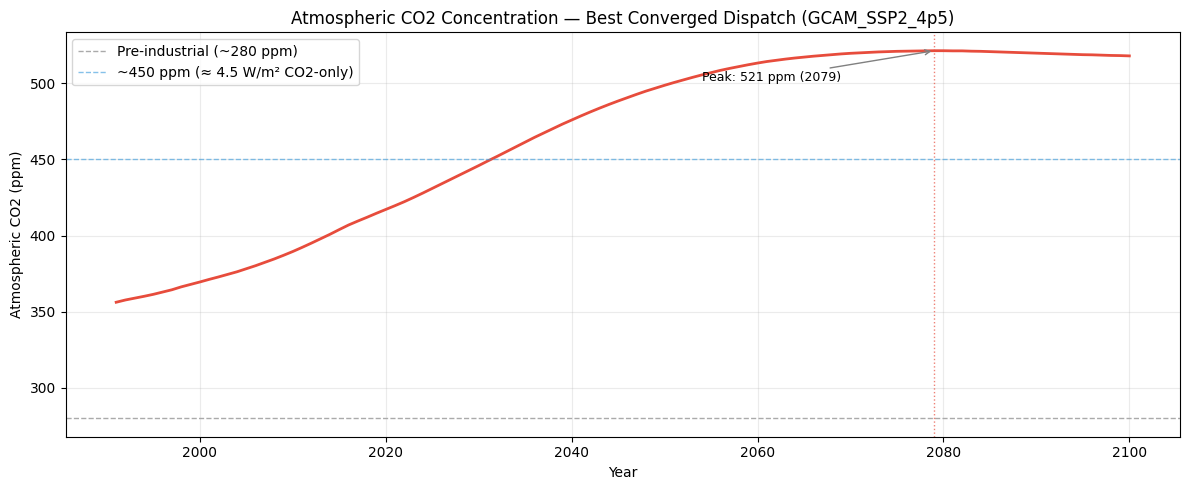

In [39]:
# ── Plot 3: CO2 concentration (ppm) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

co2_ppm = get(best_dispatch, 'CO2_concentration', 1850)
ax.plot(co2_ppm.index, co2_ppm.values, color='#e74c3c', lw=2)

ax.axhline(280, color='#aaaaaa', lw=1, ls='--', label='Pre-industrial (~280 ppm)')
ax.axhline(450, color='#3498db', lw=1, ls='--', alpha=0.6, label='~450 ppm (≈ 4.5 W/m² CO2-only)')

# Mark peak
peak_yr  = co2_ppm.idxmax()
peak_val = co2_ppm.max()
if peak_yr < 2100:
    ax.axvline(peak_yr, color='#e74c3c', lw=1, ls=':', alpha=0.7)
    ax.annotate(f'Peak: {peak_val:.0f} ppm ({peak_yr})',
                xy=(peak_yr, peak_val), xytext=(peak_yr - 25, peak_val - 20),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='grey'))

ax.set_xlabel('Year')
ax.set_ylabel('Atmospheric CO2 (ppm)')
ax.set_title('Atmospheric CO2 Concentration — Best Converged Dispatch (GCAM_SSP2_4p5)')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

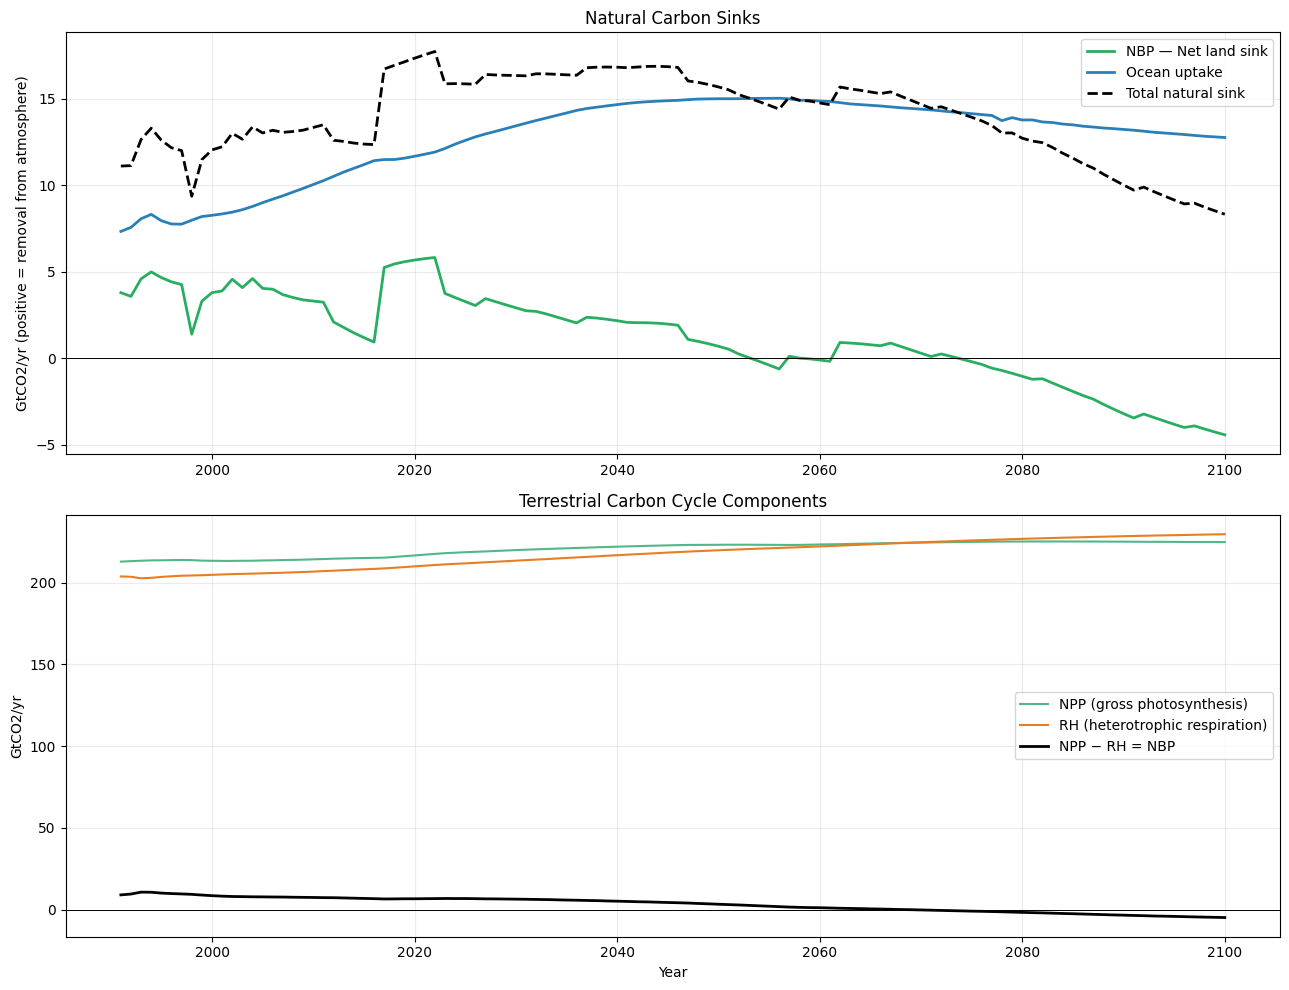

In [40]:
# ── Plot 4: Natural sinks ─────────────────────────────────────────────────────
# Hector units: Pg C/yr.  Convert to GtCO2/yr: × 44/12 ≈ × 3.667
PGC_TO_GTCO2 = 44 / 12

nbp     = get(best_dispatch, 'NBP', 1950) * PGC_TO_GTCO2
ocean   = get(best_dispatch, 'ocean_uptake', 1950) * PGC_TO_GTCO2
npp     = get(best_dispatch, 'NPP', 1950) * PGC_TO_GTCO2
rh      = get(best_dispatch, 'RH',  1950) * PGC_TO_GTCO2

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

ax = axes[0]
ax.plot(nbp.index,   nbp.values,   color='#27ae60', lw=2, label='NBP — Net land sink')
ax.plot(ocean.index, ocean.values, color='#2980b9', lw=2, label='Ocean uptake')
total_sink = nbp.add(ocean, fill_value=0)
ax.plot(total_sink.index, total_sink.values, color='black', lw=2, ls='--', label='Total natural sink')
ax.axhline(0, color='black', lw=0.7)
ax.set_ylabel('GtCO2/yr (positive = removal from atmosphere)')
ax.set_title('Natural Carbon Sinks')
ax.legend()
ax.grid(True, alpha=0.25)

ax = axes[1]
ax.plot(npp.index, npp.values, color='#52b788', lw=1.5, label='NPP (gross photosynthesis)')
ax.plot(rh.index,  rh.values,  color='#e67e22', lw=1.5, label='RH (heterotrophic respiration)')
net_land = npp.subtract(rh, fill_value=0)
ax.plot(net_land.index, net_land.values, color='black', lw=2, label='NPP − RH = NBP')
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('GtCO2/yr')
ax.set_title('Terrestrial Carbon Cycle Components')
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [41]:
# ── Load GCAM DB emissions ────────────────────────────────────────────────────
db      = gcamreader.LocalDBConn(str(DB_PATH), DB_NAME)
queries = gcamreader.parse_batch_query(str(QUERIES_PATH))

co2_q  = next(q for q in queries if q.title == 'CO2 emissions by region')

SCENARIOS = ['Reference', 'GCAM_SSP2_4p5_os', 'GCAM_SSP2_4p5_tol15', 'GCAM_SSP2_3p7', 'GCAM_SSP1_2p6', 'GCAM_SSP1_1p9']
emissions = {}
for sc in SCENARIOS:
    try:
        df_e = db.runQuery(co2_q, scenarios=[sc])
        emissions[sc] = df_e.groupby('Year')['value'].sum() / 1000  # MtCO2 → GtCO2
    except Exception as e:
        print(f'{sc}: {e}')

for sc, s in emissions.items():
    print(f'{sc}: 2100 emissions = {s.get(2100, float("nan")):.2f} GtCO2/yr')

Database scenarios: Reference, GCAM_SSP4, GCAM_SSP5, GCAM_SSP1, GCAM_SSP2, GCAM_SSP3, GCAM_SSP1_1p9, GCAM_SSP1_2p6, GCAM_SSP2_3p7, GCAM_SSP2_4p5_os, GCAM_SSP2_4p5_tol15
Reference: 2100 emissions = 13.85 GtCO2/yr
GCAM_SSP2_4p5_os: 2100 emissions = 0.80 GtCO2/yr
GCAM_SSP2_4p5_tol15: 2100 emissions = 1.98 GtCO2/yr
GCAM_SSP2_3p7: 2100 emissions = -1.95 GtCO2/yr
GCAM_SSP1_2p6: 2100 emissions = -1.85 GtCO2/yr
GCAM_SSP1_1p9: 2100 emissions = -1.94 GtCO2/yr


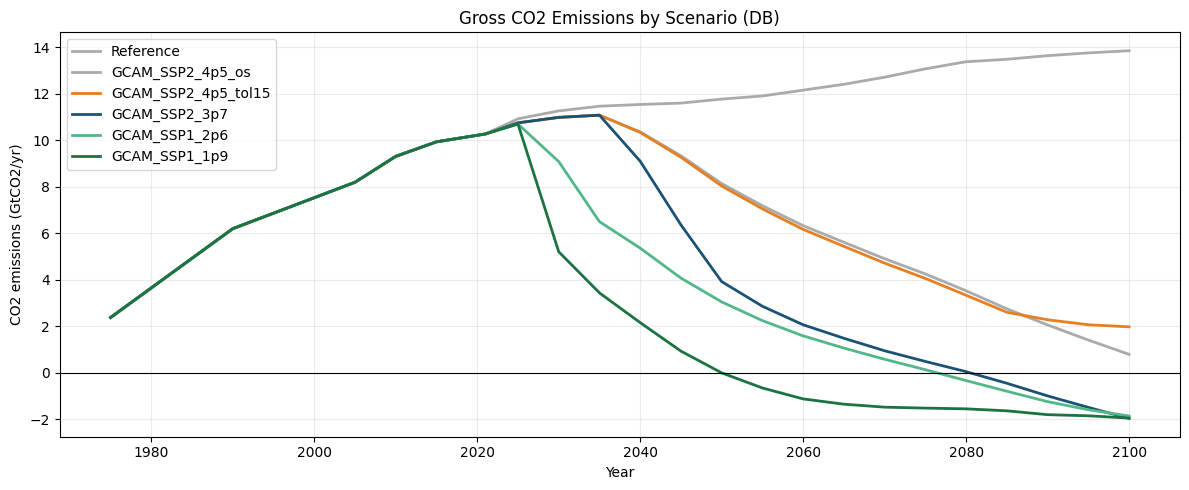

In [42]:
# ── Plot 5: CO2 emissions by scenario ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for sc, s in emissions.items():
    ax.plot(s.index, s.values, color=SCENARIO_COLORS.get(sc, '#aaaaaa'), lw=2, label=sc)

ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('CO2 emissions (GtCO2/yr)')
ax.set_title('Gross CO2 Emissions by Scenario (DB)')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

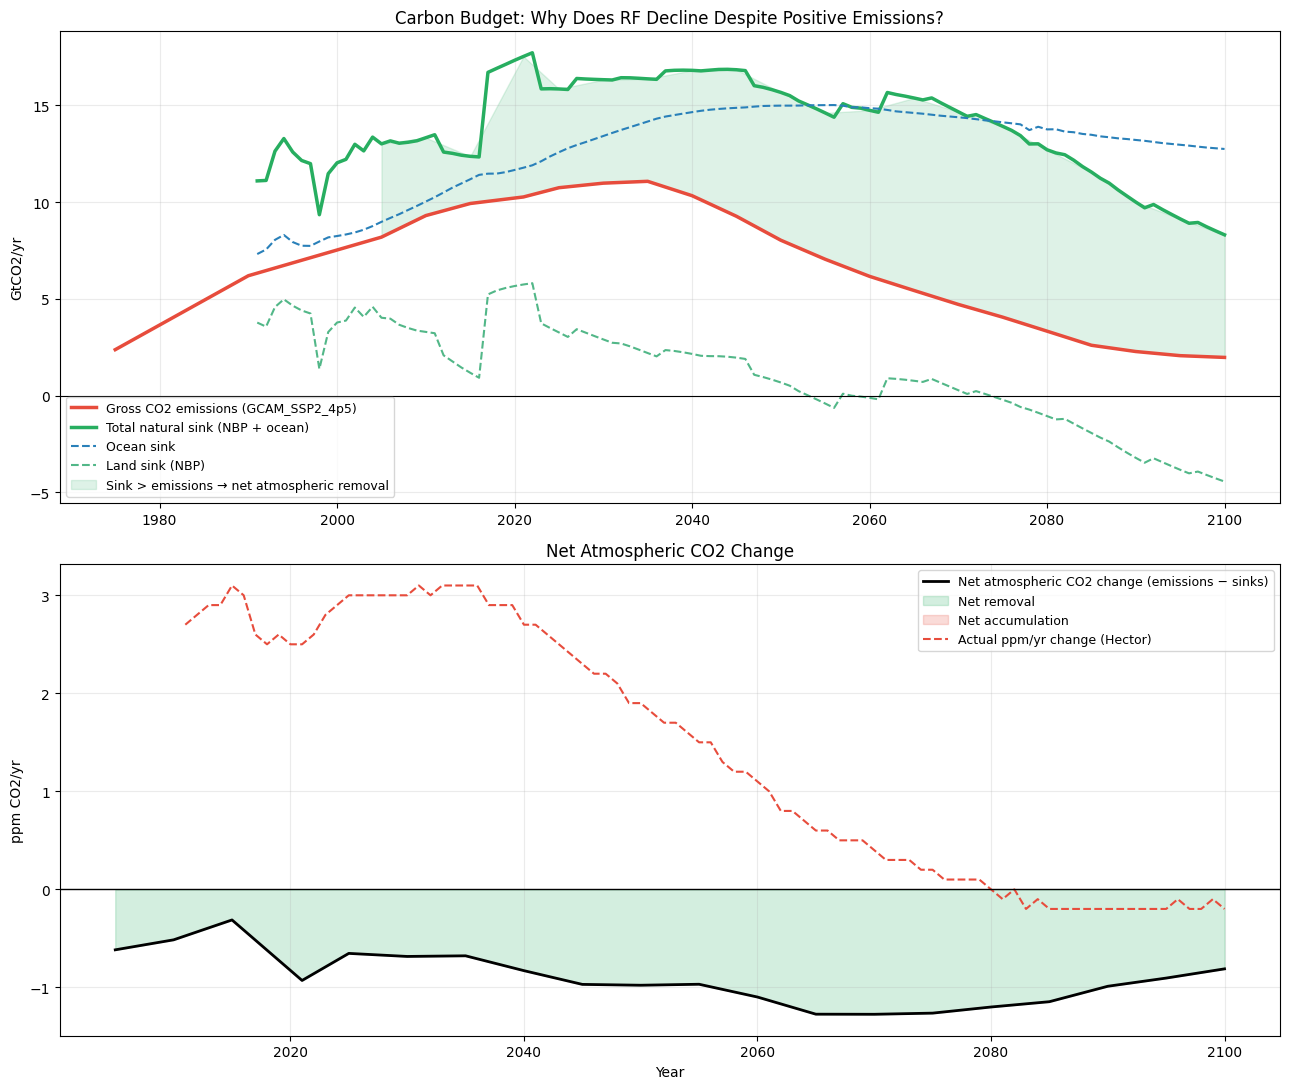

In [43]:
# ── Plot 6: Carbon budget — emissions vs sinks (the key diagnostic) ──────────
# Answers: why does RF decline when gross CO2 emissions are still positive?

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# Top: gross emissions vs total natural sink
ax = axes[0]
if 'GCAM_SSP2_4p5_tol15' in emissions:
    em = emissions['GCAM_SSP2_4p5_tol15']
    ax.plot(em.index, em.values, color='#e74c3c', lw=2.5, label='Gross CO2 emissions (GCAM_SSP2_4p5)')

ax.plot(total_sink.index, total_sink.values, color='#27ae60', lw=2.5, label='Total natural sink (NBP + ocean)')
ax.plot(ocean.index, ocean.values, color='#2980b9', lw=1.5, ls='--', label='Ocean sink')
ax.plot(nbp.index, nbp.values, color='#52b788', lw=1.5, ls='--', label='Land sink (NBP)')

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('GtCO2/yr')
ax.set_title('Carbon Budget: Why Does RF Decline Despite Positive Emissions?')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# Shade region where sink > emissions (net removal)
if 'GCAM_SSP2_4p5_tol15' in emissions:
    em_ann = emissions['GCAM_SSP2_4p5_tol15']
    common = em_ann.index.intersection(total_sink.index)
    net = em_ann.loc[common] - total_sink.loc[common]
    ax.fill_between(common, em_ann.loc[common], total_sink.loc[common],
                    where=(net.values < 0), alpha=0.15, color='#27ae60',
                    label='Sink > emissions → net atmospheric removal')
    ax.legend(fontsize=9)

# Bottom: net atmospheric CO2 change (ppm/yr implied)
ax = axes[1]
if 'GCAM_SSP2_4p5_tol15' in emissions:
    # 1 ppm CO2 ≈ 2.13 GtC ≈ 7.81 GtCO2
    GTCO2_PER_PPM = 7.81
    net_ppm = net / GTCO2_PER_PPM
    ax.plot(net_ppm.index, net_ppm.values, color='black', lw=2,
            label='Net atmospheric CO2 change (emissions − sinks)')
    ax.fill_between(net_ppm.index, 0, net_ppm.values,
                    where=(net_ppm.values < 0), alpha=0.2, color='#27ae60', label='Net removal')
    ax.fill_between(net_ppm.index, 0, net_ppm.values,
                    where=(net_ppm.values > 0), alpha=0.2, color='#e74c3c', label='Net accumulation')

    # Overlay actual ppm change from Hector
    co2_ppm_yr = get(best_dispatch, 'CO2_concentration', 2010)
    co2_ppm_chg = co2_ppm_yr.diff()
    ax.plot(co2_ppm_chg.index, co2_ppm_chg.values, color='#e74c3c', lw=1.5, ls='--',
            label='Actual ppm/yr change (Hector)')

ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Year')
ax.set_ylabel('ppm CO2/yr')
ax.set_title('Net Atmospheric CO2 Change')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

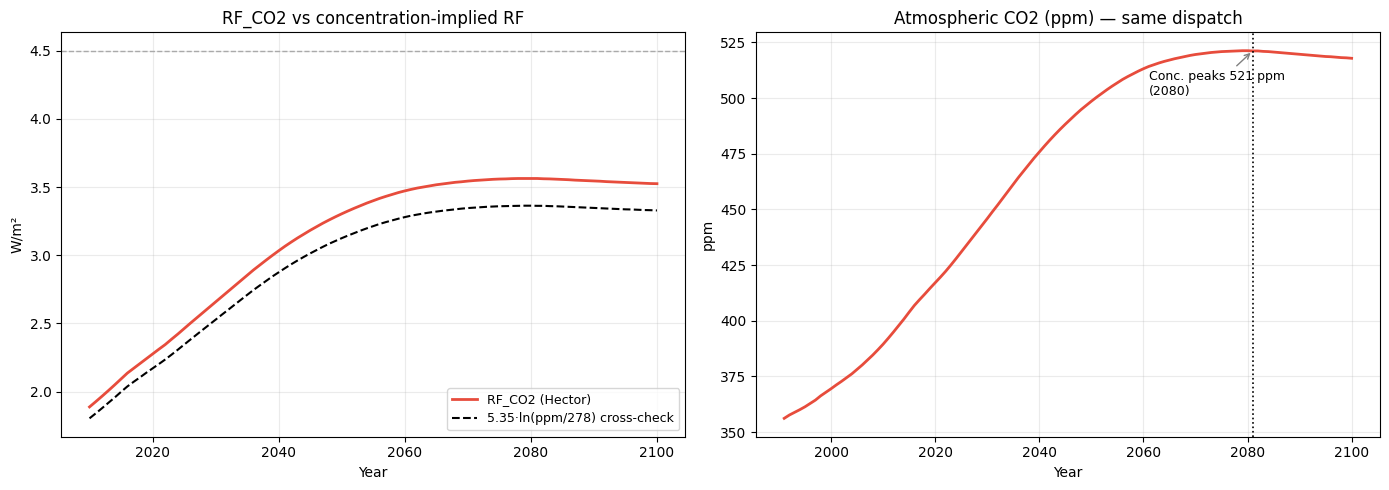

Concentration peak: 521.3 ppm in 2079
RF_CO2 at 2090: 3.5450 W/m²
RF_CO2 at 2095: 3.5340 W/m²
RF_CO2 at 2100: 3.5250 W/m²


In [44]:
# ── Plot 7: RF_CO2 vs CO2 concentration — are they consistent? ──────────────
# Hector formula: RF_CO2 = 5.35 * ln(C / 278)
# If RF_CO2 declining, C must be declining.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
rf_co2_s = get(best_dispatch, 'RF_CO2', 2010)
ax.plot(rf_co2_s.index, rf_co2_s.values, color='#e74c3c', lw=2, label='RF_CO2 (Hector)')
# Implied RF from ppm
rf_implied = 5.35 * np.log(co2_ppm.loc[co2_ppm.index >= 2010] / 278)
ax.plot(rf_implied.index, rf_implied.values, color='black', lw=1.5, ls='--',
        label='5.35·ln(ppm/278) cross-check')
ax.axhline(TARGET_4P5, color='#aaaaaa', lw=1, ls='--')
ax.set_xlabel('Year')
ax.set_ylabel('W/m²')
ax.set_title('RF_CO2 vs concentration-implied RF')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

ax = axes[1]
ax.plot(co2_ppm.index, co2_ppm.values, color='#e74c3c', lw=2)
ax.set_xlabel('Year')
ax.set_ylabel('ppm')
ax.set_title('Atmospheric CO2 (ppm) — same dispatch')
ax.grid(True, alpha=0.25)
# Mark where ppm starts declining (if it does)
ppm_chg = co2_ppm.diff()
decline_start = ppm_chg[ppm_chg < 0].first_valid_index()
if decline_start:
    ax.axvline(decline_start, color='black', lw=1.2, ls=':')
    ax.annotate(f'Conc. peaks {co2_ppm.loc[decline_start-1]:.0f} ppm\n({decline_start-1})',
                xy=(decline_start, co2_ppm.loc[decline_start]),
                xytext=(decline_start - 20, co2_ppm.loc[decline_start] - 20),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='grey'))

plt.tight_layout()
plt.show()

print(f'Concentration peak: {co2_ppm.max():.1f} ppm in {co2_ppm.idxmax()}')
print(f'RF_CO2 at 2090: {rf_co2_s.get(2090, float("nan")):.4f} W/m²')
print(f'RF_CO2 at 2095: {rf_co2_s.get(2095, float("nan")):.4f} W/m²')
print(f'RF_CO2 at 2100: {rf_co2_s.get(2100, float("nan")):.4f} W/m²')

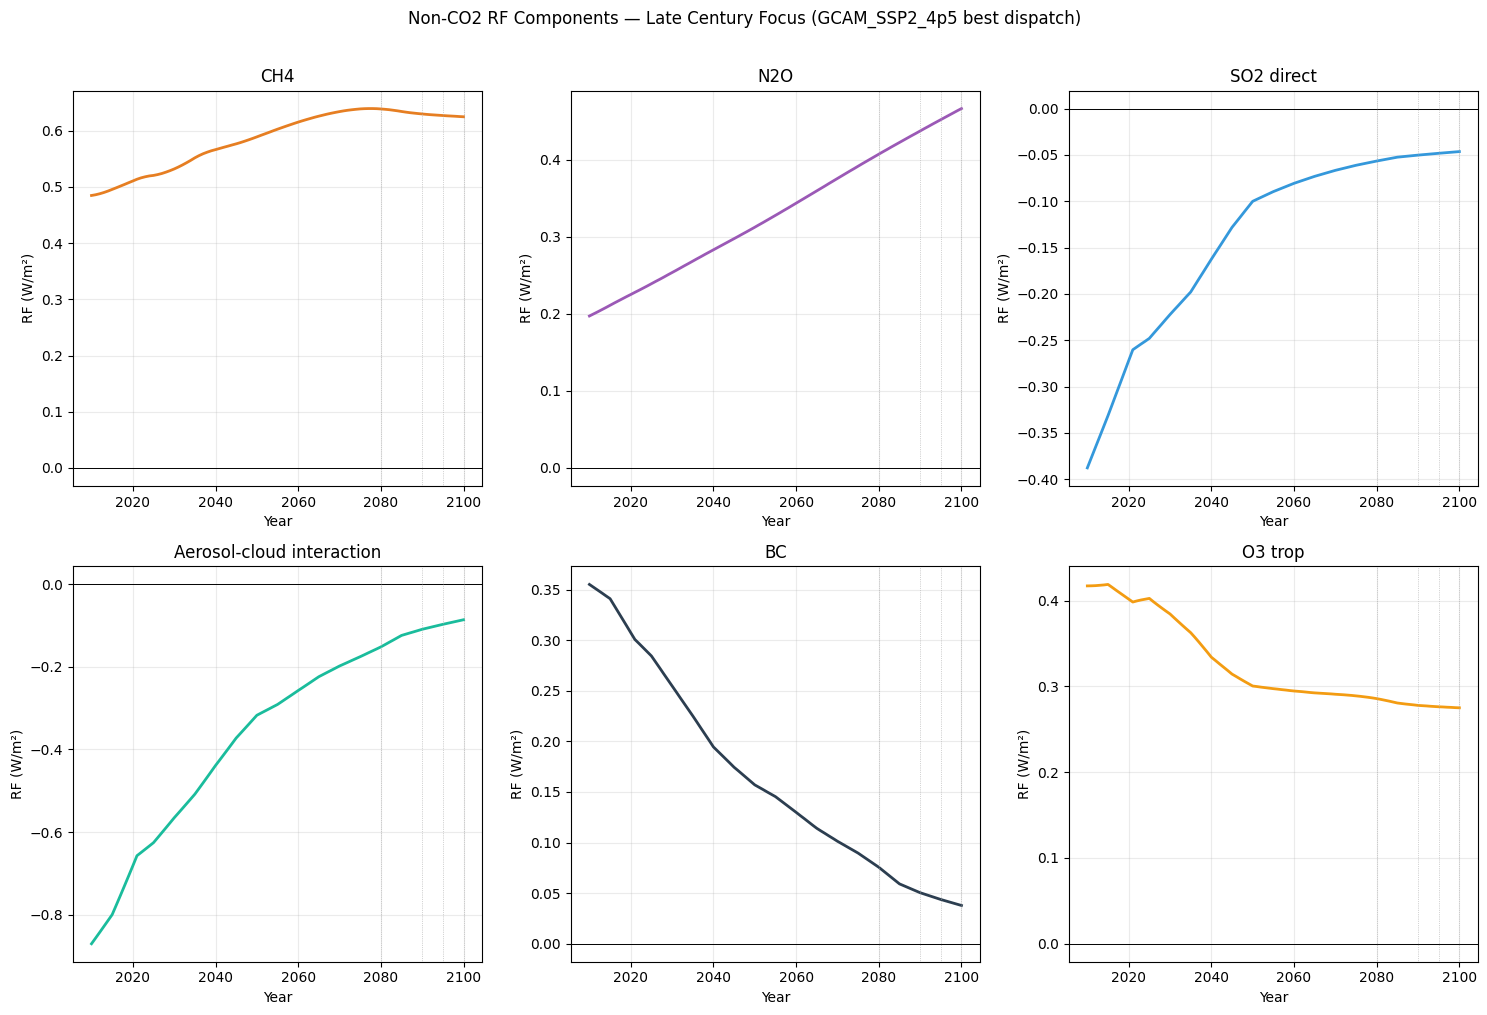

Late-century RF by component:
Component                     2085     2090     2095     2100
CO2                       3.5560 3.5450 3.5340 3.5250
CH4                       0.6344 0.6300 0.6272 0.6250
N2O                       0.4223 0.4372 0.4519 0.4663
SO2 direct                -0.0525 -0.0502 -0.0483 -0.0464
Aerosol-cloud interaction -0.1236 -0.1087 -0.0967 -0.0856
BC                        0.0592 0.0505 0.0437 0.0378
OC                        -0.0020 0.0012 0.0037 0.0060
O3 trop                   0.2806 0.2778 0.2762 0.2750
H2O strat                 0.0627 0.0622 0.0619 0.0616
Albedo                    -0.2006 -0.1947 -0.1882 -0.1814
Misc                      0.0000 0.0000 0.0000 0.0000
TOTAL                     4.4970 4.4940 4.4950 4.5010


In [45]:
# ── Plot 8: Non-CO2 forcing deep dive ────────────────────────────────────────
# Which non-CO2 component is driving total RF near target?

NON_CO2_VARS = {
    'CH4':         'FCH4',
    'N2O':         'RF_N2O',
    'SO2 direct':  'RF_SO2',
    'Aerosol-cloud interaction': 'RF_aci',
    'BC':          'RF_BC',
    'OC':          'RF_OC',
    'O3 trop':     'RF_O3_trop',
    'H2O strat':   'RF_H2O_strat',
    'Albedo':      'RF_albedo',
    'Misc':        'RF_misc',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

focus_vars = ['FCH4', 'RF_N2O', 'RF_SO2', 'RF_aci', 'RF_BC', 'RF_O3_trop']
focus_cols = ['#e67e22', '#9b59b6', '#3498db', '#1abc9c', '#2c3e50', '#f39c12']

for i, (var, col) in enumerate(zip(focus_vars, focus_cols)):
    ax = axes[i]
    s = get(best_dispatch, var, 2010)
    if not s.empty:
        ax.plot(s.index, s.values, color=col, lw=2)
        ax.axhline(0, color='black', lw=0.7)
        label = [k for k, v in NON_CO2_VARS.items() if v == var]
        ax.set_title(label[0] if label else var)
        ax.set_xlabel('Year')
        ax.set_ylabel('RF (W/m²)')
        ax.grid(True, alpha=0.25)
        # Print late-century values
        for yr in [2080, 2090, 2095, 2100]:
            if yr in s.index:
                ax.axvline(yr, color='#aaaaaa', lw=0.5, ls=':')

plt.suptitle('Non-CO2 RF Components — Late Century Focus (GCAM_SSP2_4p5 best dispatch)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Print 2090–2100 values for key components
print('Late-century RF by component:')
print(f'{"Component":<25} {"2085":>8} {"2090":>8} {"2095":>8} {"2100":>8}')
for label, var in {**{"CO2": "RF_CO2"}, **NON_CO2_VARS, **{"TOTAL": "RF_tot"}}.items():
    s = get(best_dispatch, var, 2080)
    if not s.empty:
        vals = [f'{s.get(yr, float("nan")):.4f}' for yr in [2085, 2090, 2095, 2100]]
        print(f'{label:<25} {" ".join(vals)}')

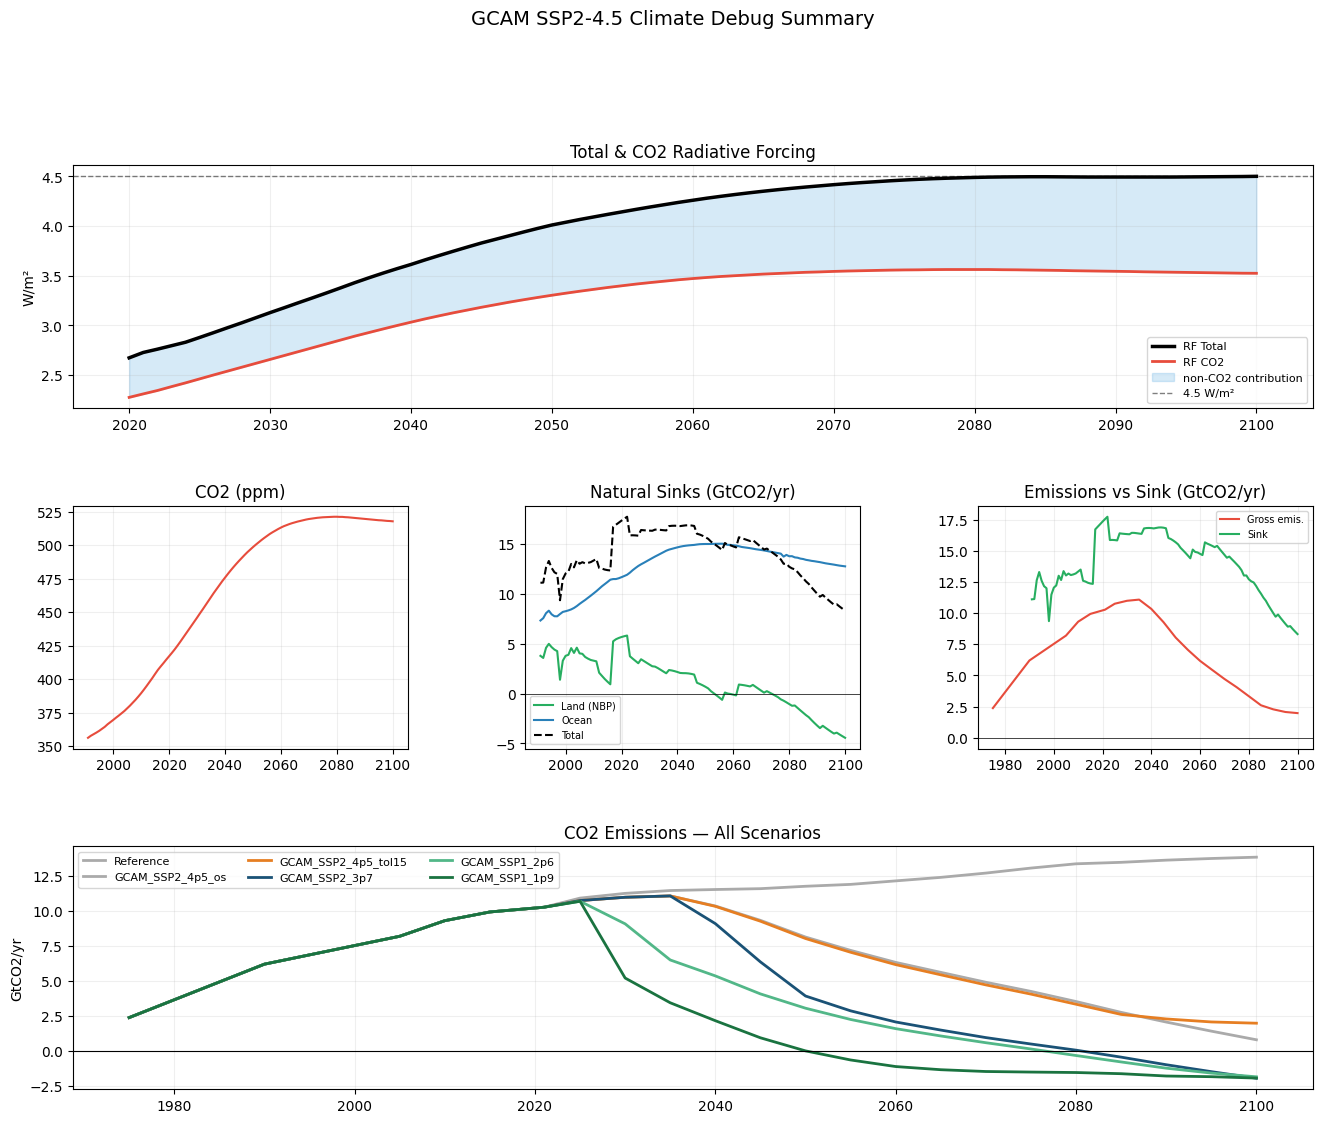

In [46]:
# ── Plot 9: Summary panel ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Total RF
ax1 = fig.add_subplot(gs[0, :])
rf_tot_s = get(best_dispatch, 'RF_tot', 2020)
rf_co2_s = get(best_dispatch, 'RF_CO2', 2020)
ax1.plot(rf_tot_s.index, rf_tot_s.values, color='black', lw=2.5, label='RF Total')
ax1.plot(rf_co2_s.index, rf_co2_s.values, color='#e74c3c', lw=2, label='RF CO2')
common_idx = rf_tot_s.index.intersection(rf_co2_s.index)
ax1.fill_between(common_idx, rf_co2_s.loc[common_idx], rf_tot_s.loc[common_idx],
                 alpha=0.2, color='#3498db', label='non-CO2 contribution')
ax1.axhline(TARGET_4P5, color='black', lw=1, ls='--', alpha=0.5, label='4.5 W/m²')
ax1.set_title('Total & CO2 Radiative Forcing')
ax1.set_ylabel('W/m²')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)

# 2. CO2 ppm
ax2 = fig.add_subplot(gs[1, 0])
co2_ppm_s = get(best_dispatch, 'CO2_concentration', 1950)
ax2.plot(co2_ppm_s.index, co2_ppm_s.values, color='#e74c3c', lw=1.5)
ax2.set_title('CO2 (ppm)')
ax2.grid(True, alpha=0.2)

# 3. Natural sinks
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(nbp.index, nbp.values, color='#27ae60', lw=1.5, label='Land (NBP)')
ax3.plot(ocean.index, ocean.values, color='#2980b9', lw=1.5, label='Ocean')
ax3.plot(total_sink.index, total_sink.values, color='black', lw=1.5, ls='--', label='Total')
ax3.axhline(0, color='black', lw=0.5)
ax3.set_title('Natural Sinks (GtCO2/yr)')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.2)

# 4. Gross emissions vs total sink
ax4 = fig.add_subplot(gs[1, 2])
if 'GCAM_SSP2_4p5_tol15' in emissions:
    em = emissions['GCAM_SSP2_4p5_tol15']
    ax4.plot(em.index, em.values, color='#e74c3c', lw=1.5, label='Gross emis.')
ax4.plot(total_sink.index, total_sink.values, color='#27ae60', lw=1.5, label='Sink')
ax4.axhline(0, color='black', lw=0.5)
ax4.set_title('Emissions vs Sink (GtCO2/yr)')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.2)

# 5. CO2 emissions all scenarios
ax5 = fig.add_subplot(gs[2, :])
for sc, s in emissions.items():
    ax5.plot(s.index, s.values, color=SCENARIO_COLORS.get(sc, '#aaaaaa'), lw=2, label=sc)
ax5.axhline(0, color='black', lw=0.8)
ax5.set_title('CO2 Emissions — All Scenarios')
ax5.set_ylabel('GtCO2/yr')
ax5.legend(fontsize=8, ncol=3)
ax5.grid(True, alpha=0.2)

plt.suptitle('GCAM SSP2-4.5 Climate Debug Summary', fontsize=14, y=1.01)
plt.show()